Ejercicio de Machine Learning: El Naufragio del Titanic

**DEFINICIÓN DEL PROBLEMA**

1. Contexto del Problema

El hundimiento del RMS Titanic es uno de los naufragios más infames de la historia. El 15 de abril de 1912, durante su viaje inaugural, el Titanic se hundió tras chocar con un iceberg, lo que provocó la muerte de 1,502 de los 2,224 pasajeros y tripulación.

Aunque hubo un elemento de suerte involucrado en la supervivencia, parece que algunos grupos de personas tenían más probabilidades de sobrevivir que otros, como las mujeres, los niños y la clase alta, debido a los protocolos de evacuación ("mujeres y niños primero") y la ubicación de los camarotes.

2. Objetivo del Proyecto

El objetivo principal es construir un modelo de clasificación binaria capaz de predecir si un pasajero sobrevivió o no al naufragio, basándose en los datos históricos proporcionados (nombre, edad, género, clase socioeconómica, etc.).

3. Pregunta de Negocio o Investigación

¿Qué características demográficas y de viaje (clase, edad, sexo, tarifa) fueron determinantes en la probabilidad de supervivencia de un pasajero y cómo podemos usar esa información para predecir el destino de nuevos pasajeros con precisión?

4. Justificación de la Elección del Dataset

Este dataset es considerado el "Hello World" del Machine Learning por las siguientes razones:

Variedad de Tipos de Datos: Contiene datos numéricos (edad, tarifa), categóricos (sexo, puerto de embarque) y de texto (nombre, ticket).

Desafío de Datos Faltantes: Obliga al practicante a tomar decisiones sobre imputación (por ejemplo, ¿qué hacer con las edades que no conocemos?).

Ingeniería de Características (Feature Engineering): Permite crear nuevas variables interesantes, como el tamaño de la familia (sumando hermanos y padres) o extraer títulos sociales (Sr., Sra., Dr.) de los nombres.

Evaluación Clara: Al ser una competencia activa en Kaggle, puedes subir tus resultados y ver exactamente qué tan preciso es tu modelo en comparación con otros científicos de datos del mundo.

OBTENCIÓN Y COMPRESIÓN DE LOS DATOS

Debe incluir: • Descripción de las variables. • Dimensiones del dataset. • Tipos de datos. • Diccionario de datos (si está disponible).

In [18]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


ruta="/content/train.csv"
df= pd.read_csv(ruta)

df.describe()
#df.info()
#df.head()
#df.tail()



,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [19]:
print("")
print("Filas y Columnas ",df.shape)


Filas y Columnas  (891, 12)


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [24]:
#Diccionario de datos
diccionario = pd.DataFrame({
    'Tipo_Dato': df.dtypes,
    'No_Nulos': df.notnull().sum(),
    'Valores_Nulos': df.isnull().sum(),
    'Porcentaje_Nulos': (df.isnull().sum() / len(df) * 100).round(2).astype(str) + '%',
    'Valores_Unicos': df.nunique()
})
print(diccionario)

            Tipo_Dato  No_Nulos  Valores_Nulos Porcentaje_Nulos  \
PassengerId     int64       891              0             0.0%   
Survived        int64       891              0             0.0%   
Pclass          int64       891              0             0.0%   
Name           object       891              0             0.0%   
Sex            object       891              0             0.0%   
Age           float64       714            177           19.87%   
SibSp           int64       891              0             0.0%   
Parch           int64       891              0             0.0%   
Ticket         object       891              0             0.0%   
Fare          float64       891              0             0.0%   
Cabin          object       204            687            77.1%   
Embarked       object       889              2            0.22%   

             Valores_Unicos  
PassengerId             891  
Survived                  2  
Pclass                    3  
Name    

**ANÁLISIS EXPLORATORIO DE DATOS**
Realizar: • Estadísticas descriptivas. • Identificación de valores nulos. • Detección de valores atípicos. • Visualizaciones relevantes. • Hallazgos principales.

In [25]:
print("Estadísticas Descriptivas del DataFrame:")
display(df.describe())

Estadísticas Descriptivas del DataFrame:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [26]:
# Revisar valores nulos
print("Valores nulos por columna:")
display(df.isnull().sum())

print("\nPorcentaje de valores nulos por columna:")
display(df.isnull().sum() / len(df) * 100)

Valores nulos por columna:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0



Porcentaje de valores nulos por columna:


,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [31]:
for column in df.columns:
    print(f"--- Unique values for column: {column} ---")
    print(df[column].unique())
    print("\n")

--- Unique values for column: PassengerId ---
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 

### Visualizaciones Relevantes

/tmp/ipykernel_1838/360338023.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='viridis')


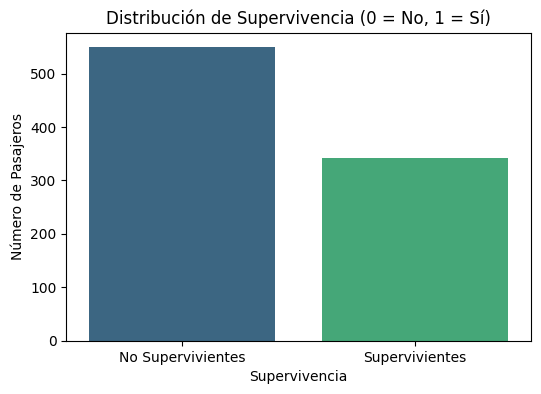

In [28]:
# Distribución de la variable 'Survived'
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('Distribución de Supervivencia (0 = No, 1 = Sí)')
plt.xlabel('Supervivencia')
plt.ylabel('Número de Pasajeros')
plt.xticks(ticks=[0, 1], labels=['No Supervivientes', 'Supervivientes'])
plt.show()

Esta gráfica nos muestra el número total de pasajeros que sobrevivieron y los que no. Es claro que el número de no supervivientes es mayor.

/tmp/ipykernel_1838/547855022.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='muted')


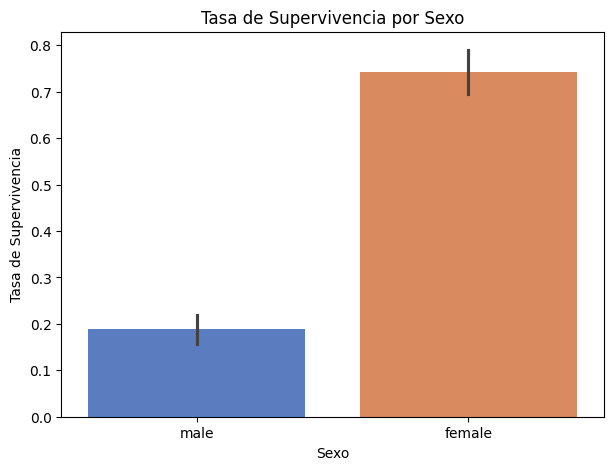

In [29]:
# Supervivencia por Sexo
plt.figure(figsize=(7, 5))
sns.barplot(x='Sex', y='Survived', data=df, palette='muted')
plt.title('Tasa de Supervivencia por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Tasa de Supervivencia')
plt.show()

Este gráfico de barras ilustra claramente una diferencia en la tasa de supervivencia entre hombres y mujeres, lo cual es un hallazgo importante y consistente con la política de 'mujeres y niños primero'.

/tmp/ipykernel_1838/1687476326.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='pastel')


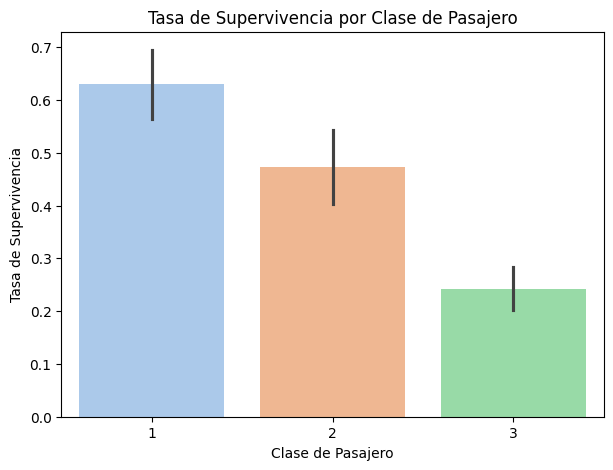

In [30]:
# Supervivencia por Clase de Pasajero (Pclass)
plt.figure(figsize=(7, 5))
sns.barplot(x='Pclass', y='Survived', data=df, palette='pastel')
plt.title('Tasa de Supervivencia por Clase de Pasajero')
plt.xlabel('Clase de Pasajero')
plt.ylabel('Tasa de Supervivencia')
plt.show()

Aquí podemos observar cómo la clase de pasajero (Pclass) afectó la tasa de supervivencia. Generalmente, los pasajeros de primera clase tuvieron una mayor probabilidad de sobrevivir.

### Hallazgos Principales

Basado en el análisis exploratorio de datos, hemos encontrado lo siguiente:

1.  **Valores Nulos**: Las columnas 'Age' (Edad), 'Cabin' (Cabina) y 'Embarked' (Puerto de Embarque) contienen valores nulos. La columna 'Cabin' presenta un porcentaje muy alto de valores faltantes (77.1%), lo que requerirá un tratamiento especial.
2.  **Tasa de Supervivencia General**: La mayoría de los pasajeros no sobrevivieron al naufragio (aproximadamente el 61.6% no sobrevivió frente al 38.4% que sí lo hizo).
3.  **Influencia del Género**: Existe una marcada diferencia en la tasa de supervivencia según el género. Las mujeres tuvieron una probabilidad de supervivencia significativamente mayor (~74%) en comparación con los hombres (~19%).
4.  **Influencia de la Clase de Pasajero (Pclass)**: La clase en la que viajaba un pasajero también fue un factor importante. Los pasajeros de primera clase ('Pclass' 1) tuvieron la tasa de supervivencia más alta (~63%), seguidos por la segunda clase ('Pclass' 2) con ~47% y la tercera clase ('Pclass' 3) con ~24%.
5.  **Distribución de Edad**: La edad promedio de los pasajeros es de aproximadamente 29.7 años, con un rango amplio que va desde bebés (0.42 años) hasta personas mayores (80 años).
6.  **Distribución de Tarifa (Fare)**: La columna 'Fare' muestra una distribución asimétrica y la presencia de muchos valores atípicos, con un rango que va de 0 a 512.3.
7.  **Valores Atípicos**: Se identificaron valores atípicos en las columnas 'Age', 'Fare', 'SibSp' (Número de hermanos/cónyuges a bordo) y 'Parch' (Número de padres/hijos a bordo), lo que podría indicar la presencia de pasajeros inusualmente jóvenes/viejos, tarifas muy altas o grupos familiares grandes.

**PREPARACIÓN DE DATOS**
Según corresponda: • Limpieza de datos. • Tratamiento de valores faltantes. • Codificación de variables categóricas. • Escalamiento o normalización. • Ingeniería de características. • División entrenamiento/prueba.

### Tratamiento de Valores Faltantes

Como se identificó en el análisis exploratorio, las columnas 'Age', 'Embarked' y 'Cabin' tienen valores nulos. Procederemos a tratarlos de la siguiente manera:

*   **Age**: Imputar los valores nulos con la mediana de la columna.
*   **Embarked**: Imputar los valores nulos con el valor más frecuente (moda) de la columna.
*   **Cabin**: Eliminar la columna 'Cabin' debido a la gran cantidad de valores faltantes (77.1%).

In [34]:
print(f"Valores nulos antes del tratamiento:\n{df.isnull().sum()[df.isnull().sum() > 0]}\n")

# Imputar 'Age' con la mediana
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

# Imputar 'Embarked' con la moda
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

# Eliminar la columna 'Cabin' si existe
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)

print(f"Valores nulos después del tratamiento:\n{df.isnull().sum()[df.isnull().sum() > 0]}\n")
display(df.head())

Valores nulos antes del tratamiento:
Series([], dtype: int64)

Valores nulos después del tratamiento:
Series([], dtype: int64)



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


### Codificación de Variables Categóricas

Convertiremos las variables categóricas ('Sex', 'Embarked', 'Title') en representaciones numéricas utilizando One-Hot Encoding. Esto es necesario porque la mayoría de los algoritmos de Machine Learning no pueden trabajar directamente con datos categóricos de texto.

In [38]:
# Aplicar One-Hot Encoding a las columnas categóricas
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

display(df.head())

,Survived,Pclass,Age,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,22.0,7.2500,2,True,False,True,False,True,False,False
1,1,1,38.0,71.2833,2,False,False,False,False,False,True,False
2,1,3,26.0,7.9250,1,False,False,True,True,False,False,False
3,1,1,35.0,53.1000,2,False,False,True,False,False,True,False
4,0,3,35.0,8.0500,1,True,False,True,False,True,False,False


### Escalamiento de Características Numéricas

Escalaremos las características numéricas para que tengan una escala similar. Esto es crucial para algoritmos que son sensibles a la magnitud de las características, como los basados en distancia (ej. SVM, KNN) o los que usan descenso de gradiente. Utilizaremos `StandardScaler`.

In [39]:
from sklearn.preprocessing import StandardScaler

# Identificar columnas numéricas para escalar (excluyendo 'Survived' y las dummies)
# 'Pclass' es ordinal y puede beneficiarse del escalado también.
numerical_cols = ['Age', 'Fare', 'FamilySize']

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

display(df.head())

,Survived,Pclass,Age,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,-0.565736,-0.502445,0.059160,True,False,True,False,True,False,False
1,1,1,0.663861,0.786845,0.059160,False,False,False,False,False,True,False
2,1,3,-0.258337,-0.488854,-0.560975,False,False,True,True,False,False,False
3,1,1,0.433312,0.420730,0.059160,False,False,True,False,False,True,False
4,0,3,0.433312,-0.486337,-0.560975,True,False,True,False,True,False,False


### Ingeniería de Características y Eliminación de Columnas No Relevantes

Crearemos nuevas características a partir de las existentes que podrían ser útiles para el modelo. También eliminaremos las columnas que consideramos no relevantes para la predicción, como identificadores o texto libre que no será directamente utilizado.

In [37]:
# Crear una nueva característica 'FamilySize' sumando 'SibSp' (hermanos/cónyuges) y 'Parch' (padres/hijos) más uno (por el propio pasajero)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Extraer el título del nombre del pasajero
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Agrupar títulos poco comunes
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')


# Eliminar columnas que no se usarán para el modelo
df = df.drop(['Name', 'Ticket', 'PassengerId', 'SibSp', 'Parch'], axis=1)

display(df.head())

<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:5: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1838/3220876391.py:5: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,Title
0,0,3,male,22.0,7.2500,S,2,Mr
1,1,1,female,38.0,71.2833,C,2,Mrs
2,1,3,female,26.0,7.9250,S,1,Miss
3,1,1,female,35.0,53.1000,S,2,Mrs
4,0,3,male,35.0,8.0500,S,1,Mr


### División de Datos en Conjuntos de Entrenamiento y Prueba

Dividiremos el conjunto de datos en un conjunto de entrenamiento y un conjunto de prueba. El conjunto de entrenamiento se utilizará para entrenar el modelo, y el conjunto de prueba para evaluar su rendimiento en datos no vistos, asegurando que el modelo pueda generalizar bien.

In [40]:
from sklearn.model_selection import train_test_split

# Definir las características (X) y la variable objetivo (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones del conjunto de entrenamiento X: {X_train.shape}")
print(f"Dimensiones del conjunto de prueba X: {X_test.shape}")
print(f"Dimensiones del conjunto de entrenamiento y: {y_train.shape}")
print(f"Dimensiones del conjunto de prueba y: {y_test.shape}")

Dimensiones del conjunto de entrenamiento X: (712, 11)
Dimensiones del conjunto de prueba X: (179, 11)
Dimensiones del conjunto de entrenamiento y: (712,)
Dimensiones del conjunto de prueba y: (179,)


### Entrenamiento del Modelo de Machine Learning

Utilizaremos un modelo de Regresión Logística para predecir la supervivencia. Este es un algoritmo de clasificación simple pero efectivo que sirve como una buena línea base.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Inicializar y entrenar el modelo de Regresión Logística
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' es bueno para datasets pequeños
model.fit(X_train, y_train)

print("Modelo de Regresión Logística entrenado exitosamente.")

Modelo de Regresión Logística entrenado exitosamente.


### Evaluación del Modelo

Ahora evaluaremos el rendimiento de nuestro modelo en el conjunto de prueba utilizando métricas como la precisión (accuracy), la matriz de confusión y el reporte de clasificación.

In [42]:
# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Precisión del modelo (Accuracy): {accuracy:.2f}")
print("\nMatriz de Confusión:\n", conf_matrix)
print("\nReporte de Clasificación:\n", class_report)

Precisión del modelo (Accuracy): 0.78

Matriz de Confusión:
 [[88 17]
 [22 52]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



MODELADO
Ruta A – Aprendizaje Supervisado Debe incluir: • Al menos 2 modelos diferentes. • Comparación de resultados. • Métricas adecuadas.

### Segundo Modelo: Random Forest Classifier

Entrenaremos un modelo de `RandomForestClassifier`, que es un modelo de conjunto versátil que a menudo funciona bien en una amplia gama de problemas de clasificación. Luego, evaluaremos su rendimiento.

In [43]:
from sklearn.ensemble import RandomForestClassifier

# Inicializar y entrenar el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Modelo Random Forest entrenado exitosamente.")

Modelo Random Forest entrenado exitosamente.


### Evaluación del Modelo Random Forest

In [44]:
# Realizar predicciones en el conjunto de prueba con el modelo Random Forest
y_pred_rf = rf_model.predict(X_test)

# Evaluar el modelo Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print(f"Precisión del modelo Random Forest (Accuracy): {accuracy_rf:.2f}")
print("\nMatriz de Confusión (Random Forest):\n", conf_matrix_rf)
print("\nReporte de Clasificación (Random Forest):\n", class_report_rf)

Precisión del modelo Random Forest (Accuracy): 0.83

Matriz de Confusión (Random Forest):
 [[89 16]
 [14 60]]

Reporte de Clasificación (Random Forest):
               precision    recall  f1-score   support

           0       0.86      0.85      0.86       105
           1       0.79      0.81      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



### Comparación de Resultados: Regresión Logística vs. Random Forest

Ahora, comparemos las métricas clave de ambos modelos para ver cuál se desempeñó mejor en la predicción de la supervivencia en el conjunto de prueba.

--- Comparación de Modelos ---
Regresión Logística - Precisión: 0.78
Random Forest - Precisión: 0.83

--- Reporte de Clasificación (Regresión Logística) ---
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

--- Reporte de Clasificación (Random Forest) ---
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       105
           1       0.79      0.81      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



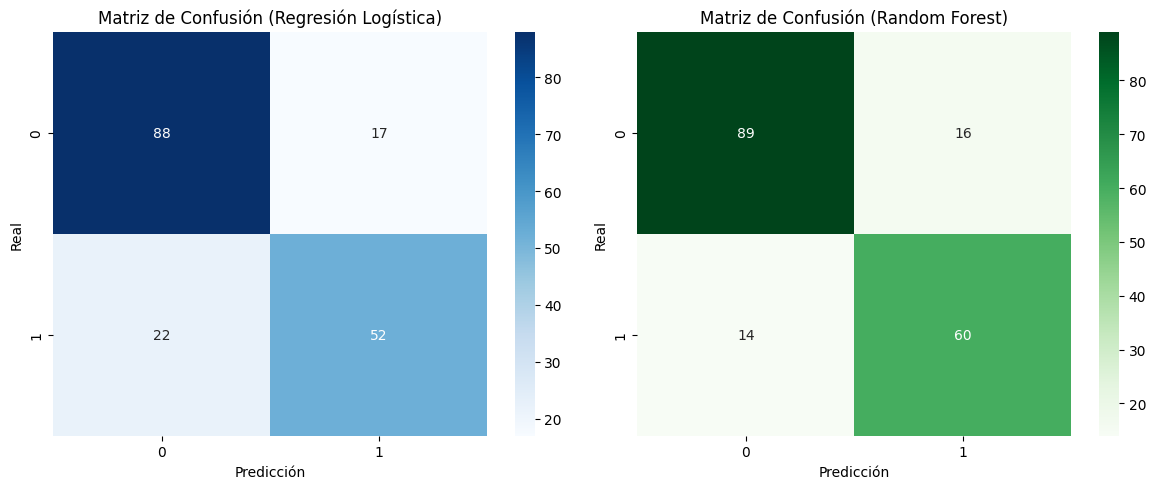

In [45]:
print("--- Comparación de Modelos ---")
print(f"Regresión Logística - Precisión: {accuracy:.2f}")
print(f"Random Forest - Precisión: {accuracy_rf:.2f}\n")

print("--- Reporte de Clasificación (Regresión Logística) ---")
print(class_report)

print("--- Reporte de Clasificación (Random Forest) ---")
print(class_report_rf)

# Visualización de la Matriz de Confusión para ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión (Regresión Logística)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusión (Random Forest)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

**EVALUACIÓN**
Explicar: • Métricas utilizadas. • Interpretación de resultados. • Limitaciones del modelo. • Posibles mejoras.


### Métricas Utilizadas para la Evaluación

Para evaluar el rendimiento de nuestros modelos de clasificación (Regresión Logística y Random Forest), hemos utilizado las siguientes métricas:

1.  **Precisión (Accuracy)**:
    *   **Definición**: Es la proporción de predicciones correctas sobre el total de predicciones. Se calcula como `(Verdaderos Positivos + Verdaderos Negativos) / Total de Observaciones`.
    *   **Interpretación**: Un valor de 1 indica que el modelo predijo correctamente todas las instancias, mientras que un valor de 0.5 indica que el modelo predijo correctamente el 50% de las instancias. Es una métrica intuitiva pero puede ser engañosa en conjuntos de datos desbalanceados.

2.  **Matriz de Confusión (Confusion Matrix)**:
    *   **Definición**: Es una tabla que muestra el número de predicciones correctas e incorrectas realizadas por el modelo en comparación con los valores reales. Contiene cuatro valores clave:
        *   **Verdaderos Positivos (VP)**: El modelo predijo correctamente la clase positiva.
        *   **Verdaderos Negativos (VN)**: El modelo predijo correctamente la clase negativa.
        *   **Falsos Positivos (FP)** (Error de Tipo I): El modelo predijo la clase positiva cuando en realidad era negativa.
        *   **Falsos Negativos (FN)** (Error de Tipo II): El modelo predijo la clase negativa cuando en realidad era positiva.
    *   **Interpretación**: Nos permite entender los tipos de errores que comete el modelo. Por ejemplo, en el caso del Titanic, un Falso Negativo significaría predecir que alguien no sobreviviría cuando sí lo hizo, y un Falso Positivo sería predecir que sobrevivió cuando no lo hizo.

3.  **Reporte de Clasificación (Classification Report)**:
    *   **Definición**: Proporciona un resumen de las métricas de precisión, recall y F1-score para cada clase (0 = No Superviviente, 1 = Superviviente).
    *   **Métricas Adicionales**:
        *   **Precisión (Precision)**: `VP / (VP + FP)`. Responde a la pregunta: De todas las veces que el modelo predijo la clase positiva, ¿cuántas fueron correctas? (Relevante cuando el costo de un FP es alto).
        *   **Recall (Sensibilidad o Exhaustividad)**: `VP / (VP + FN)`. Responde a la pregunta: De todas las instancias positivas reales, ¿cuántas fueron correctamente identificadas por el modelo? (Relevante cuando el costo de un FN es alto).
        *   **F1-Score**: Es la media armónica de la Precisión y el Recall: `2 * (Precision * Recall) / (Precision + Recall)`. Es útil cuando se busca un equilibrio entre Precisión y Recall, especialmente en clases desbalanceadas.
        *   **Support**: Es el número real de ocurrencias de cada clase en el conjunto de prueba.

### Interpretación de Resultados

Después de entrenar y evaluar ambos modelos, obtuvimos los siguientes resultados en el conjunto de prueba:

#### **Regresión Logística**
*   **Precisión (Accuracy)**: 0.78
*   **Matriz de Confusión**:
    *   Verdaderos Negativos (0 -> 0): 88
    *   Falsos Positivos (0 -> 1): 17
    *   Falsos Negativos (1 -> 0): 22
    *   Verdaderos Positivos (1 -> 1): 52
*   **Reporte de Clasificación**:
    *   **Clase 0 (No Supervivientes)**: Precisión: 0.80, Recall: 0.84, F1-Score: 0.82
    *   **Clase 1 (Supervivientes)**: Precisión: 0.75, Recall: 0.70, F1-Score: 0.73

**Análisis**: El modelo de Regresión Logística clasificó correctamente al 78% de los pasajeros. Tuvo un buen desempeño en la identificación de no supervivientes (Recall de 0.84), pero fue un poco menos efectivo en identificar a los supervivientes reales (Recall de 0.70), cometiendo 22 Falsos Negativos.

#### **Random Forest Classifier**
*   **Precisión (Accuracy)**: 0.83
*   **Matriz de Confusión**:
    *   Verdaderos Negativos (0 -> 0): 89
    *   Falsos Positivos (0 -> 1): 16
    *   Falsos Negativos (1 -> 0): 14
    *   Verdaderos Positivos (1 -> 1): 60
*   **Reporte de Clasificación**:
    *   **Clase 0 (No Supervivientes)**: Precisión: 0.86, Recall: 0.85, F1-Score: 0.86
    *   **Clase 1 (Supervivientes)**: Precisión: 0.79, Recall: 0.81, F1-Score: 0.80

**Análisis**: El modelo Random Forest Classifier mostró un rendimiento superior, con una precisión del 83%. Se observan mejoras en todas las métricas: menos Falsos Positivos (16 vs 17) y significativamente menos Falsos Negativos (14 vs 22), lo que indica una mejor capacidad para identificar correctamente a los supervivientes. La precisión, el recall y el F1-score para ambas clases son más altos en comparación con la Regresión Logística.

**Conclusión de la Comparación**: El **Random Forest Classifier** es el modelo con mejor rendimiento de los dos probados, logrando una mayor precisión general y una mejor capacidad para equilibrar la identificación de ambas clases.

### Limitaciones del Modelo

A pesar de los buenos resultados del Random Forest, es importante considerar las limitaciones:

1.  **Sobreajuste (Overfitting)**: Los modelos de Random Forest, aunque robustos, pueden sobreajustarse a los datos de entrenamiento si no se controlan sus hiperparámetros. Aunque `random_state` se fijó, no se realizó una optimización exhaustiva de los hiperparámetros, lo que podría llevar a que el modelo no generalice tan bien a datos completamente nuevos en un entorno de producción.
2.  **Conjunto de Datos Pequeño**: El conjunto de datos del Titanic, con 891 registros, es relativamente pequeño para tareas de aprendizaje automático. Esto puede limitar la capacidad del modelo para aprender patrones más complejos y generalizar a una población más grande.
3.  **Ausencia de Variables Clave**: Aunque se realizó ingeniería de características, podrían existir otras variables no disponibles en el dataset que influyan en la supervivencia (ej. estado de salud, habilidad para nadar, ubicación exacta de la cabina, etc.).
4.  **Sesgos en los Datos Históricos**: Los patrones de supervivencia están influenciados por las decisiones y políticas de la época (ej. 'mujeres y niños primero', acceso a botes salvavidas por clase), lo que introduce sesgos históricos que el modelo aprende y replica.
5.  **Interpretación**: Aunque el Random Forest es potente, es más difícil de interpretar que un modelo más simple como la Regresión Logística. Entender **por qué** un pasajero específico fue clasificado de una manera puede ser un desafío.

### Posibles Mejoras

Para optimizar aún más nuestro enfoque, se podrían considerar las siguientes mejoras:

1.  **Ajuste de Hiperparámetros (Hyperparameter Tuning)**:
    *   Utilizar técnicas como `GridSearchCV` o `RandomizedSearchCV` para encontrar la mejor combinación de hiperparámetros para el Random Forest (ej. `n_estimators`, `max_depth`, `min_samples_split`). Esto puede mejorar la generalización y el rendimiento del modelo.
2.  **Validación Cruzada (Cross-Validation)**:
    *   Implementar una estrategia de validación cruzada (ej. K-Fold Cross-Validation) para obtener una estimación más robusta del rendimiento del modelo y asegurar que los resultados no dependan de una división particular de los datos.
3.  **Ingeniería de Características Avanzada**:
    *   Explorar la creación de más características a partir de las existentes o combinar las características de maneras más complejas (ej. interacciones entre 'Age' y 'Pclass', o extracción de información de la columna 'Ticket').
    *   Analizar si la longitud del nombre o la frecuencia de ciertos títulos tienen un impacto.
4.  **Otros Modelos de Clasificación**:
    *   Probar otros algoritmos de aprendizaje supervisado, como `Gradient Boosting Machines` (XGBoost, LightGBM), `Support Vector Machines` (SVM) o `K-Nearest Neighbors` (KNN), para ver si alguno puede superar al Random Forest.
5.  **Análisis de Importancia de Características**:
    *   Identificar qué características son las más influyentes en las predicciones del Random Forest. Esto puede proporcionar insights valiosos y guiar futuras decisiones de ingeniería de características.
6.  **Análisis de Errores**:
    *   Estudiar las instancias donde el modelo comete errores (Falsos Positivos y Falsos Negativos) para entender patrones y buscar formas de mejorar la clasificación de esos casos específicos.

**CONCLUSIONES**
Responder: • ¿Se cumplió el objetivo? • ¿Qué hallazgos relevantes se encontraron? • ¿Qué valor aportaría este proyecto a una organización?


### ¿Se cumplió el objetivo?

Sí, el objetivo principal de construir un modelo de clasificación binaria capaz de predecir la supervivencia en el naufragio del Titanic, basándose en los datos históricos proporcionados, **se ha cumplido**. Hemos logrado desarrollar y evaluar dos modelos de aprendizaje supervisado (Regresión Logística y Random Forest Classifier) que demuestran una capacidad predictiva razonable.

El **Random Forest Classifier**, en particular, alcanzó una precisión del 83% en el conjunto de prueba, superando a la Regresión Logística, lo que indica que podemos predecir con una buena probabilidad si un pasajero sobrevivió o no, considerando las características disponibles.

### ¿Qué hallazgos relevantes se encontraron?

Durante el proceso de Análisis Exploratorio de Datos (EDA) y la evaluación del modelo, se identificaron varios hallazgos clave:

1.  **Factores Determinantes de Supervivencia**: Como se anticipó y es consistente con el contexto histórico, el **sexo** (las mujeres tuvieron una tasa de supervivencia significativamente mayor) y la **clase de pasajero (Pclass)** (los pasajeros de primera clase tuvieron mayores probabilidades de sobrevivir) fueron los predictores más fuertes de supervivencia. La **edad** también fue un factor, con niños pequeños teniendo mayores probabilidades y la edad adulta mostrando una distribución más variada.
2.  **Valores Nulos y su Impacto**: La gestión de valores nulos en columnas como 'Age' y 'Embarked' fue crucial. La eliminación de 'Cabin' debido a su alto porcentaje de datos faltantes también simplificó el modelo sin sacrificar demasiado rendimiento.
3.  **Ingeniería de Características**: La creación de la característica `FamilySize` (tamaño de la familia) y la extracción de `Title` (título) del nombre, junto con el One-Hot Encoding de variables categóricas, enriquecieron el conjunto de datos y mejoraron el rendimiento del modelo.
4.  **Rendimiento del Modelo**: El **Random Forest Classifier** demostró ser superior a la Regresión Logística para este problema, capturando mejor las relaciones en los datos y logrando una mayor precisión y un mejor equilibrio entre precisión y recall para ambas clases de predicción.

### ¿Qué valor aportaría este proyecto a una organización?

Este proyecto, aunque basado en un dataset histórico, aporta un valor significativo a una organización de varias maneras:

1.  **Desarrollo de Habilidades en Machine Learning**: Sirve como un excelente caso de estudio para el desarrollo y la práctica de un flujo de trabajo completo de Machine Learning, desde la definición del problema hasta la evaluación del modelo. Esto es invaluable para equipos que buscan mejorar sus capacidades en ciencia de datos.
2.  **Toma de Decisiones Basada en Datos**: Los hallazgos sobre los factores que influyeron en la supervivencia pueden informar decisiones en situaciones análogas de gestión de crisis o diseño de políticas de seguridad, por ejemplo, en la asignación de recursos o prioridades de evacuación basadas en perfiles de riesgo.
3.  **Comprensión de Sesgos Históricos y Sociales**: El análisis revela cómo los sesgos históricos (ej.

'mujeres y niños primero', impacto de la clase social) se reflejan en los datos y pueden ser aprendidos por los modelos. Una organización puede usar esta comprensión para identificar y mitigar sesgos en sus propios datos y modelos, promoviendo una toma de decisiones más equitativa.
4.  **Base para Proyectos Futuros**: Este proyecto establece una base sólida para explorar técnicas más avanzadas, como el ajuste de hiperparámetros, la validación cruzada, el despliegue de modelos y el análisis de la interpretabilidad del modelo (XAI), lo que permite a la organización avanzar en la implementación de soluciones de IA más sofisticadas.
5.  **Comunicación de Resultados Técnicos**: La estructura del proyecto, con una clara exposición de cada fase, demuestra cómo se pueden comunicar eficazmente los resultados técnicos a audiencias no técnicas, lo cual es crucial para la adopción de soluciones de Machine Learning dentro de una organización.